# Analisis de datos German Creadit Score

Se va a realizar un pequeño analisis de datos sobre el dataset German credit score propuesto por (Hofmann, H. (1994). Statlog (German Credit Data) [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5NC77.) sin embargo vamos a utilizar un dataset modificado base que lo adapta a un dataset mas sencillo de leer bajo los lineamientos propuestos en el dataset original. (https://www.kaggle.com/datasets/jumpingdino/german-credit-dataset)

## 0. Librerias

In [37]:
import numpy as np
import pandas as pd

from joblib import dump, load

import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats

import phik

## 1. Carga de datos

In [38]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 50)

db_location = 'german_credit_data.csv'

credit_df=pd.read_csv(db_location, sep=',', encoding = "ISO-8859-1") 

In [39]:
credit_df.shape

(1000, 21)

In [40]:
credit_df.head(5)

,status_account,month_duration,credit_history,purpose,credit_amount,status_savings,years_employment,payment_to_income_ratio,status_and_sex,secondary_obligor,residence_since,collateral,age,other_installment_plans,housing,n_credits,job,n_guarantors,telephone,is_foreign_worker,target
0,< 0 DM,6,critical account/ other credits existing (not ...,radio/television,1169,unknown/ no savings account,>= 7 years,4,male : single,none,4,none,67,none,own,2,skilled employee/ official,1,"yes, registered under the customers name",yes,good
1,0 to < 200 DM,48,existing credits paid back duly till now,radio/television,5951,< 100 DM,1 to < 4 years,2,female : divorced/separated/married,none,2,none,22,none,own,1,skilled employee/ official,1,none,yes,bad
2,no checking account,12,critical account/ other credits existing (not ...,education,2096,< 100 DM,4 to < 7 years,2,male : single,none,3,none,49,none,own,1,unskilled - resident,2,none,yes,good
3,< 0 DM,42,existing credits paid back duly till now,furniture/equipment,7882,< 100 DM,4 to < 7 years,2,male : single,guarantor,4,car,45,none,for free,1,skilled employee/ official,2,none,yes,good
4,< 0 DM,24,delay in paying off in the past,car (new),4870,< 100 DM,1 to < 4 years,3,male : single,none,4,savings agreement/life insurance,53,none,for free,2,skilled employee/ official,2,none,yes,bad


## 2. Entendimiento de los datos

En el dataset se encuentran las siguientes columnas:

1. status_account: Estado de la cuenta corriente existente en DM (Deutsche Marks)
2. month_duration: Duración del crédito en meses
3. credit_history: Historial crediticio del solicitante
4. purpose: Propósito del crédito
5. credit_amount: Monto del crédito
6. status_savings: Estado de la cuenta de ahorros en DM (Deutsche Marks)
7. years_employment: Antigüedad en el empleo actual
8. payment_to_income_ratio: Tasa de la cuota como porcentaje del ingreso disponible
9. status_and_sex: Categorías de estado civil y sexo
10. secondary_obligor: Otros deudores / garantes
11. residence_since: Años en la residencia actual
12. collateral: Posible garantía (colateral) para el préstamo
13. age: Edad en años
14. other_installment_plans: Otros planes de pago a plazos
15. housing: Indicador de la vivienda actual (alquilada, propia o gratuita)
16. n_credits: Número de créditos existentes en este banco
job: Categorías de empleo
17. n_guarantors: Número de personas a cargo del solicitante
18. telephone: Indicador de si el cliente tiene un teléfono registrado a su nombre
19. is_foreign_worker: Indicador de si el trabajador es extranjero
20. target: Bueno para los clientes que pagaron el préstamo correctamente, malo en caso contrario

### 2.1 Completitud

In [41]:
credit_df.isnull().sum() / credit_df.shape[0]

status_account             0.0
month_duration             0.0
credit_history             0.0
purpose                    0.0
credit_amount              0.0
status_savings             0.0
years_employment           0.0
payment_to_income_ratio    0.0
status_and_sex             0.0
secondary_obligor          0.0
residence_since            0.0
collateral                 0.0
age                        0.0
other_installment_plans    0.0
housing                    0.0
n_credits                  0.0
job                        0.0
n_guarantors               0.0
telephone                  0.0
is_foreign_worker          0.0
target                     0.0
dtype: float64

### 2.2 Unicidad

In [42]:
duplicated_rows = credit_df.loc[credit_df.duplicated(keep=False)]
duplicated_rows.shape[0]

0

## 3. Selección de las variables de entrada

Vamos a revisar la correlación entre las variables del dataset y la variable objetivo **target** para seleccionar un sub conjunto de variables con el fin de simplificar la codificación en el computador cuantico.

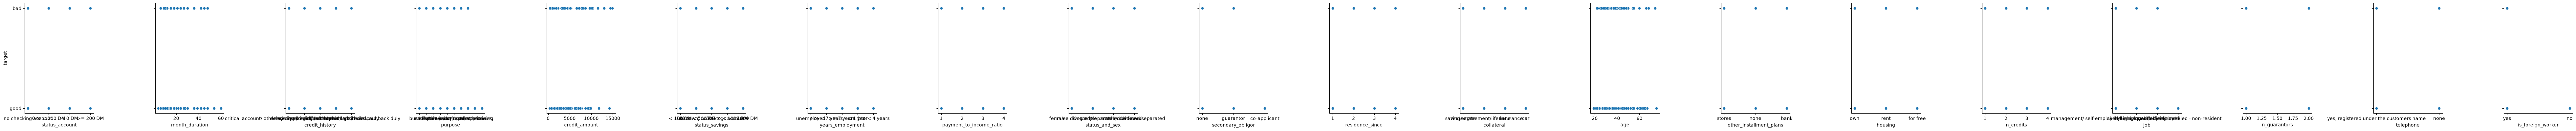

In [43]:
atributos = credit_df.columns[credit_df.columns != "target"]
sns.pairplot(credit_df.sample(frac=0.2), height=4, y_vars="target", x_vars=atributos, kind="scatter") 

### 3.1 Codificación de variables ordinales

**status_account**, **status_savings** y **years_employment** son categóricas pero tienen un orden natural (a mayor categoría, mayor solvencia/antigüedad), por lo que se codifican como enteros ordenados en lugar de con un one-hot. El resto de columnas de texto (**purpose**, **job**, **housing**, etc.) son nominales, sin orden, así que no se codifican aquí.

In [44]:
status_account_order = {
    "no checking account": 0,
    "< 0 DM": 1,
    "0 to < 200 DM": 2,
    ">= 200 DM": 3,
}

status_savings_order = {
    "unknown/ no savings account": 0,
    "< 100 DM": 1,
    "100 to < 500 DM": 2,
    "500 to < 1000 DM": 3,
    ">= 1000 DM": 4,
}

years_employment_order = {
    "unemployed": 0,
    "< 1 year": 1,
    "1 to < 4 years": 2,
    "4 to < 7 years": 3,
    ">= 7 years": 4,
}

credit_df["status_account_ord"] = credit_df["status_account"].map(status_account_order)
credit_df["status_savings_ord"] = credit_df["status_savings"].map(status_savings_order)
credit_df["years_employment_ord"] = credit_df["years_employment"].map(years_employment_order)

ordinal_cols = ["status_account_ord", "status_savings_ord", "years_employment_ord"]
assert credit_df[ordinal_cols].isnull().sum().sum() == 0, "Hay categorías sin mapear"

credit_df[ordinal_cols].head()

,status_account_ord,status_savings_ord,years_employment_ord
0,1,0,4
1,2,1,2
2,0,1,3
3,1,1,3
4,1,1,2


In [45]:
pearsonCols = ["month_duration", "credit_amount", "payment_to_income_ratio", "residence_since", "age", "n_credits", "n_guarantors"]

<Axes: >

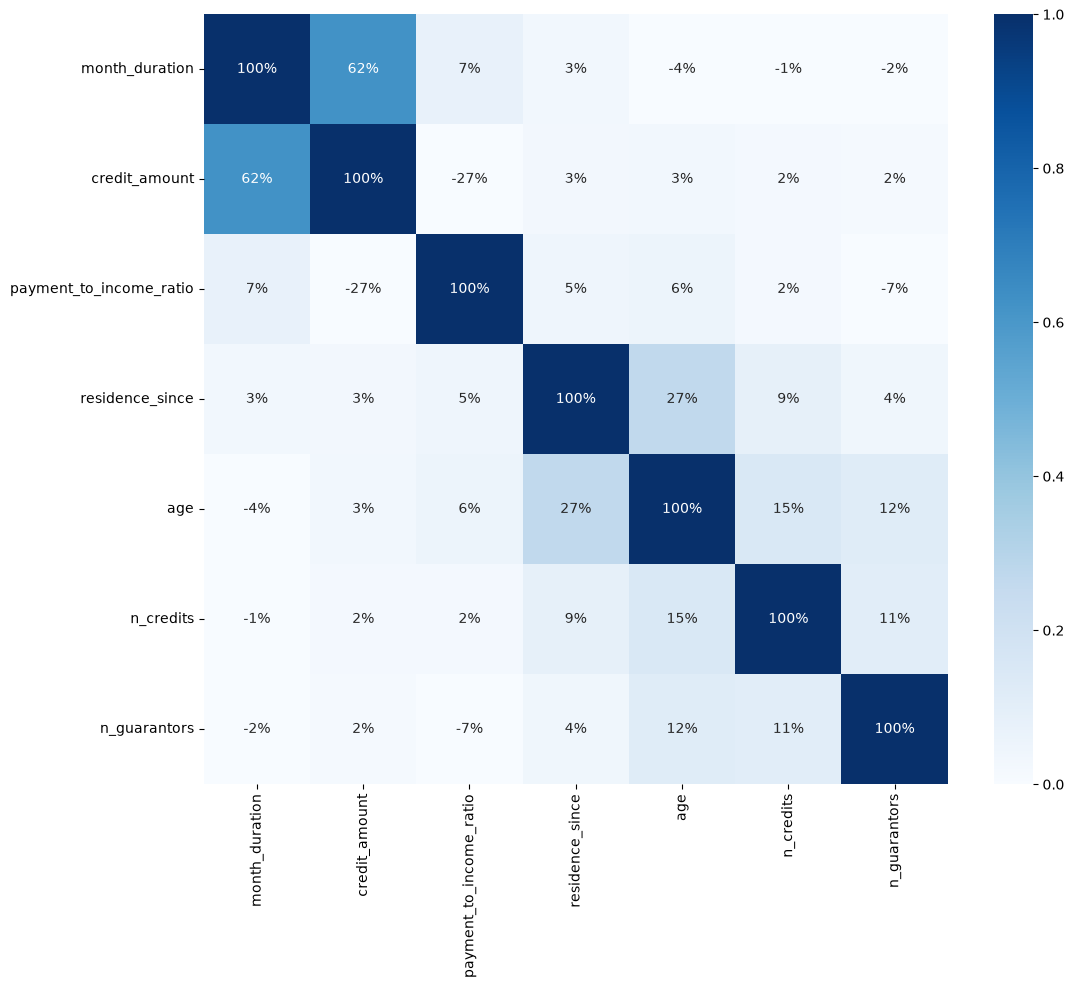

In [46]:
plt.figure(figsize=(12, 10))
sns.heatmap(credit_df[pearsonCols].corr(), cmap="Blues", vmin=0, vmax=1, annot=True, fmt=".0%")

### 3.3 Matriz de correlación con Phik (todas las variables)

A diferencia de Pearson, Phik calcula una medida de asociación (0 a 1) directamente sobre variables categóricas nominales, ordinales e intervalos numéricos combinados, sin necesitar codificación previa. Se usan las columnas ordinales ya codificadas (`_ord`) en vez de sus versiones de texto para no duplicar la misma información, y se incluye `target` sin codificar.

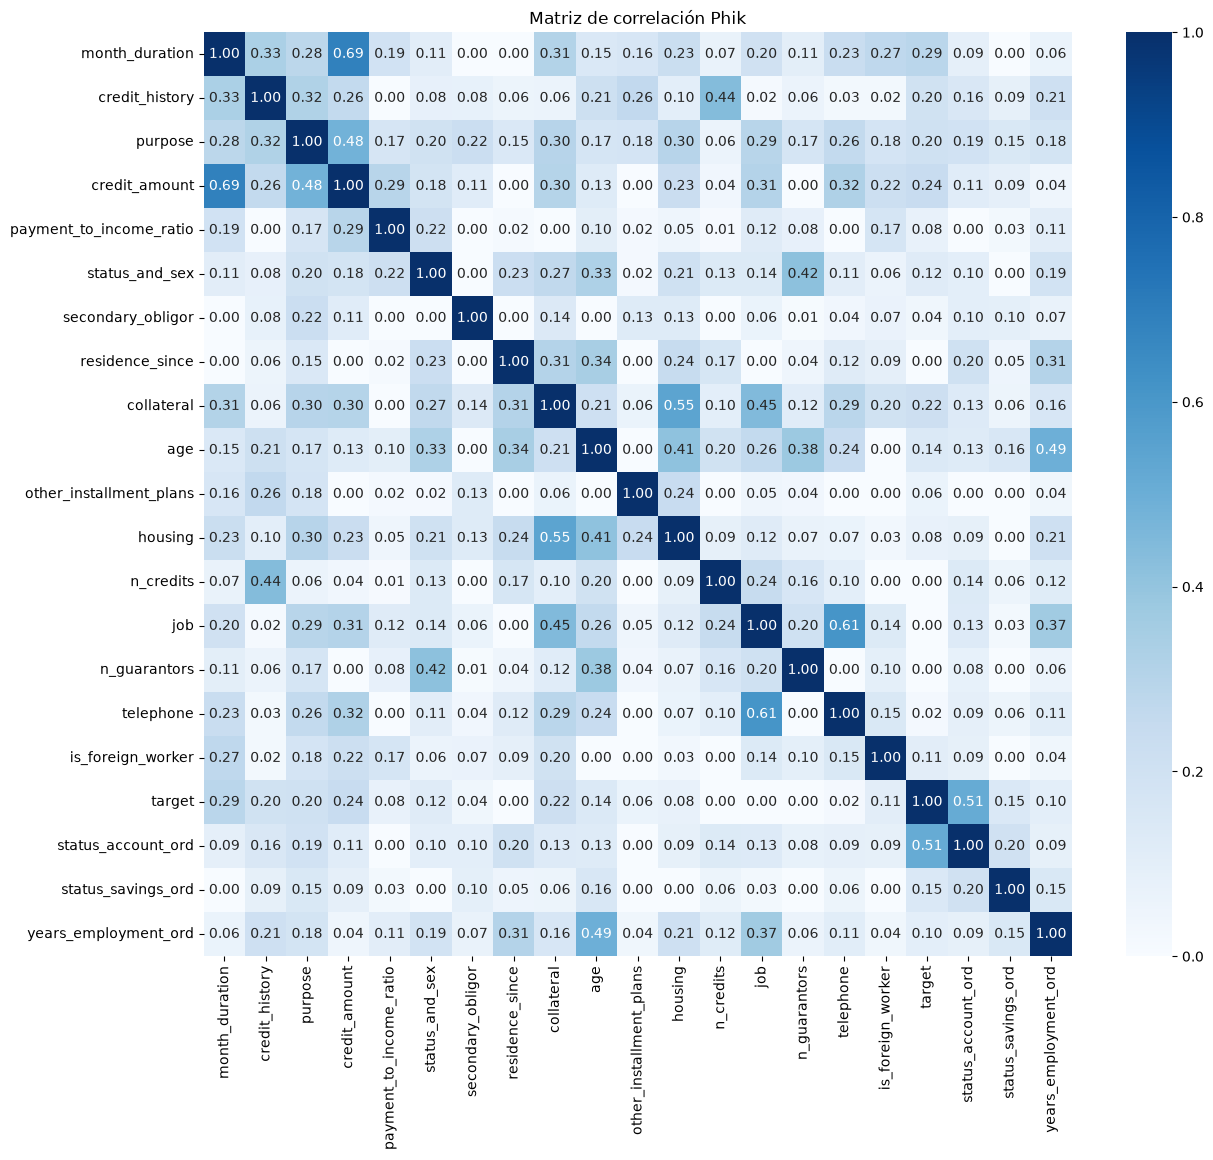

In [47]:
phik_cols = [c for c in credit_df.columns if c not in ["status_account", "status_savings", "years_employment"]]
interval_cols = pearsonCols + ["status_account_ord", "status_savings_ord", "years_employment_ord"]

phik_matrix = credit_df[phik_cols].phik_matrix(interval_cols=interval_cols)

plt.figure(figsize=(14, 12))
sns.heatmap(phik_matrix, cmap="Blues", vmin=0, vmax=1, annot=True, fmt=".2f")
plt.title("Matriz de correlación Phik")
plt.show()

In [48]:
phik_matrix["target"].sort_values(ascending=False)

target                     1.000000
status_account_ord         0.512074
month_duration             0.285273
credit_amount              0.241072
collateral                 0.217130
purpose                    0.204494
credit_history             0.196876
status_savings_ord         0.146780
age                        0.141584
status_and_sex             0.122863
is_foreign_worker          0.108911
years_employment_ord       0.098172
housing                    0.076848
payment_to_income_ratio    0.075278
other_installment_plans    0.062824
secondary_obligor          0.041100
telephone                  0.020644
n_credits                  0.000000
job                        0.000000
n_guarantors               0.000000
residence_since            0.000000
Name: target, dtype: float64

### 3.4 Significancia de las asociaciones (Phik)

El valor de phik mide la fuerza de una asociación, pero no si esa fuerza pudo surgir por azar dado el tamaño de la muestra. `significance_matrix` calcula, para cada par de variables, un puntaje Z bajo la hipótesis nula de independencia (chi² observado vs. su distribución esperada, usando el método asintótico o una simulación cuando las tablas son dispersas). Como regla práctica, |Z| > 3 se considera significativo (aprox. equivalente a p < 0.001).

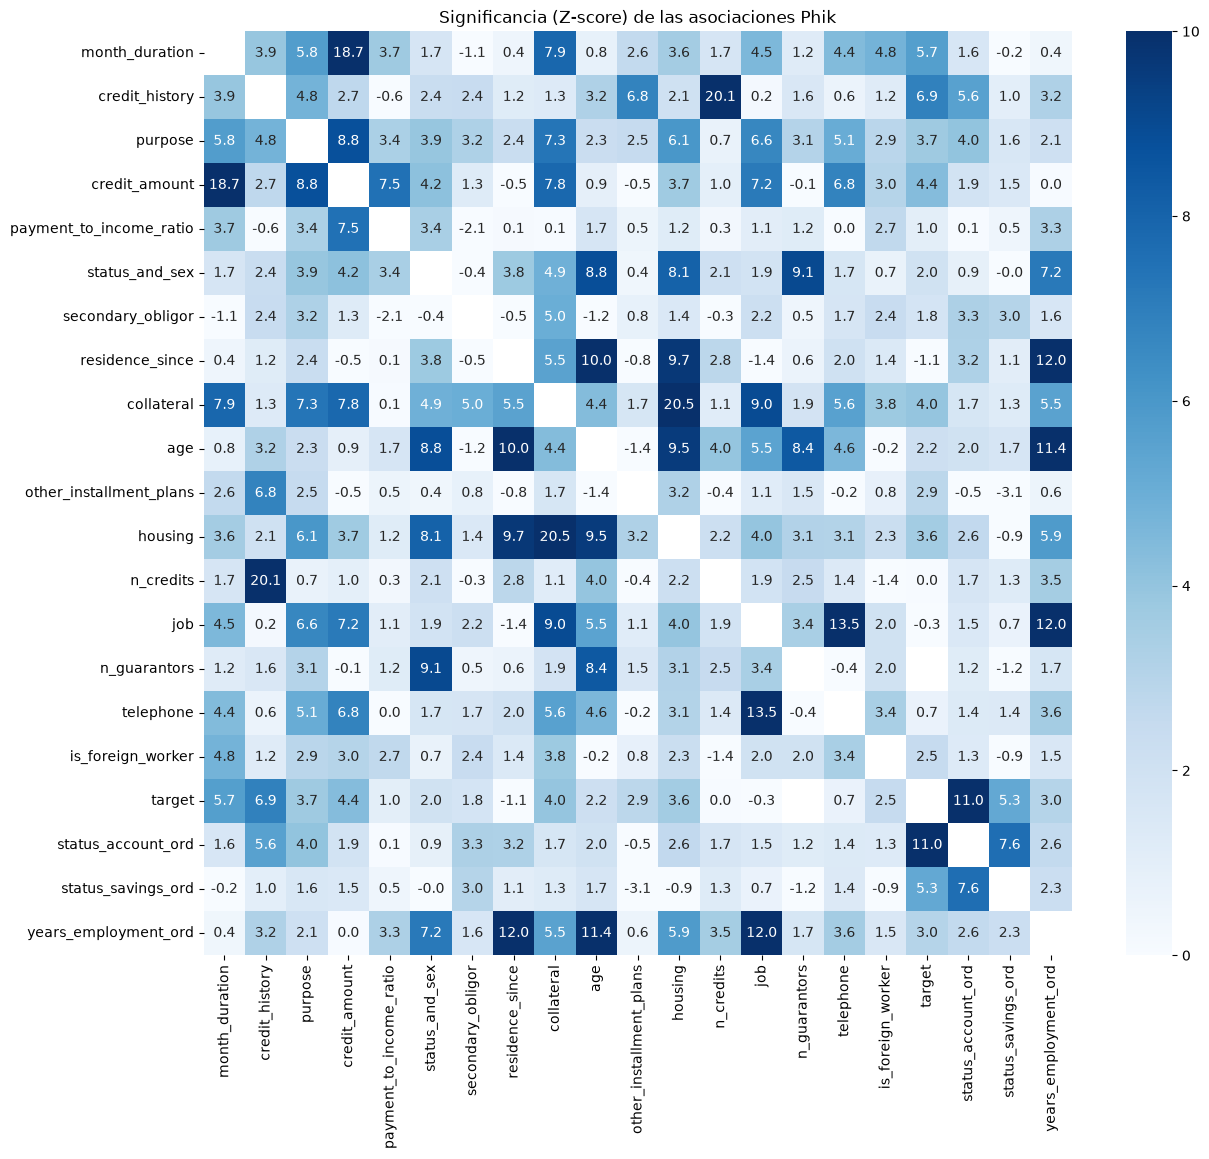

In [62]:
significance_matrix = credit_df[phik_cols].significance_matrix(interval_cols=interval_cols)

significance_plot = significance_matrix.replace([np.inf, -np.inf], np.nan)
for col in significance_plot.columns:
    significance_plot.loc[col, col] = np.nan

plt.figure(figsize=(14, 12))
sns.heatmap(significance_plot, cmap="Blues", vmin=0, vmax=10, annot=True, fmt=".1f")
plt.title("Significancia (Z-score) de las asociaciones Phik")
plt.show()

In [65]:
target_summary = pd.DataFrame({
    "phik": phik_matrix["target"],
    "significance_z": significance_matrix["target"],
}).drop(index="target").sort_values("phik", ascending=False)

target_summary["significant"] = target_summary["significance_z"] > 3
target_summary

,phik,significance_z,significant
status_account_ord,0.512074,10.956904,True
month_duration,0.285273,5.674664,True
credit_amount,0.241072,4.358661,True
collateral,0.217130,3.978959,True
purpose,0.204494,3.735707,True
credit_history,0.196876,6.887514,True
status_savings_ord,0.146780,5.270209,True
age,0.141584,2.175218,False
status_and_sex,0.122863,1.963763,False
is_foreign_worker,0.108911,2.534835,False


Gracias a esta correlación nos vamos a quedar por lo tanto con las siguientes columnas:

1. status_account: Estado de la cuenta corriente existente en DM (Deutsche Marks)
2. month_duration: Duración del crédito en meses
3. credit_amount: Monto del crédito
4. collateral: Posible garantía (colateral) para el préstamo
5. purpose: Propósito del crédito
6. credit_history: Historial crediticio del solicitante
7. housing: Indicador de la vivienda actual (alquilada, propia o gratuita)
8. years_employment: Antigüedad en el empleo actual
9. status_savings: Estado de la cuenta de ahorros en DM (Deutsche Marks)

In [69]:
final_cols = ["status_account_ord", 
              "month_duration", 
              "credit_amount", 
              "collateral", 
              "purpose", 
              "credit_history", 
              "housing", 
              "years_employment_ord",
              "status_savings_ord"]

In [70]:
final_df = credit_df[final_cols + ["target"]].copy()

In [71]:
final_df.head(5)

,status_account_ord,month_duration,credit_amount,collateral,purpose,credit_history,housing,years_employment_ord,status_savings_ord,target
0,1,6,1169,none,radio/television,critical account/ other credits existing (not ...,own,4,0,good
1,2,48,5951,none,radio/television,existing credits paid back duly till now,own,2,1,bad
2,0,12,2096,none,education,critical account/ other credits existing (not ...,own,3,1,good
3,1,42,7882,car,furniture/equipment,existing credits paid back duly till now,for free,3,1,good
4,1,24,4870,savings agreement/life insurance,car (new),delay in paying off in the past,for free,2,1,bad
